# REXAI Project - Session 1

## 1. Importing Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Data Exploration and Visualization

In [2]:
df = pd.read_csv("data/RH_dataset.csv", sep=";", encoding="utf-8")
df.head()

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23857 entries, 0 to 23856
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              23857 non-null  object 
 1   Dernière promotion (mois)     23857 non-null  float64
 2   Dernière augmentation (mois)  23857 non-null  float64
 3   Début de contrat (années)     23857 non-null  float64
 4   Ancienneté groupe (années)    23857 non-null  float64
 5   Etablissement                 23857 non-null  int64  
 6   Âge (années)                  23857 non-null  int64  
 7   Parent                        23857 non-null  int64  
 8   Niveau hiérarchique           23857 non-null  int64  
 9   Salaire (Euros)               23857 non-null  int64  
 10  Statut marital                23857 non-null  object 
 11  Véhicule                      23857 non-null  int64  
 12  matricule                     23857 non-null  int64  
 13  l

In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=[object]).columns
assert len(num_cols) + len(cat_cols) == df.shape[1], "Some columns are not categorized correctly."

In [5]:
col_to_category = {}
for col in cat_cols:
    unique_values = df[col].unique().tolist()
    col_to_category[col] = unique_values
    print(f"Column: {col}, Unique Values: {unique_values}")

Column: Famille d'emploi, Unique Values: ['Production', 'Commercial/Business', 'Etudes & Technique', 'Support', 'IT', 'Développement Immobilier', 'Matériel/Equipement', 'Management']
Column: Statut marital, Unique Values: ['Marié(e)', 'PACS', 'Célibataire', 'Divorcé(e)', 'Union libre', 'Concubin', 'Séparé(e)', 'Veuf(ve)', 'ex PACS']


In [6]:
# Hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)
df_encoded.head()

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,...,Famille d'emploi_Support,Statut marital_Concubin,Statut marital_Célibataire,Statut marital_Divorcé(e),Statut marital_Marié(e),Statut marital_PACS,Statut marital_Séparé(e),Statut marital_Union libre,Statut marital_Veuf(ve),Statut marital_ex PACS
0,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,0,...,0,0,0,0,1,0,0,0,0,0
1,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,1,...,0,0,0,0,1,0,0,0,0,0
2,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,1,...,0,0,0,0,0,1,0,0,0,0
3,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,0,...,0,0,1,0,0,0,0,0,0,0
4,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,1,...,0,0,0,0,1,0,0,0,0,0


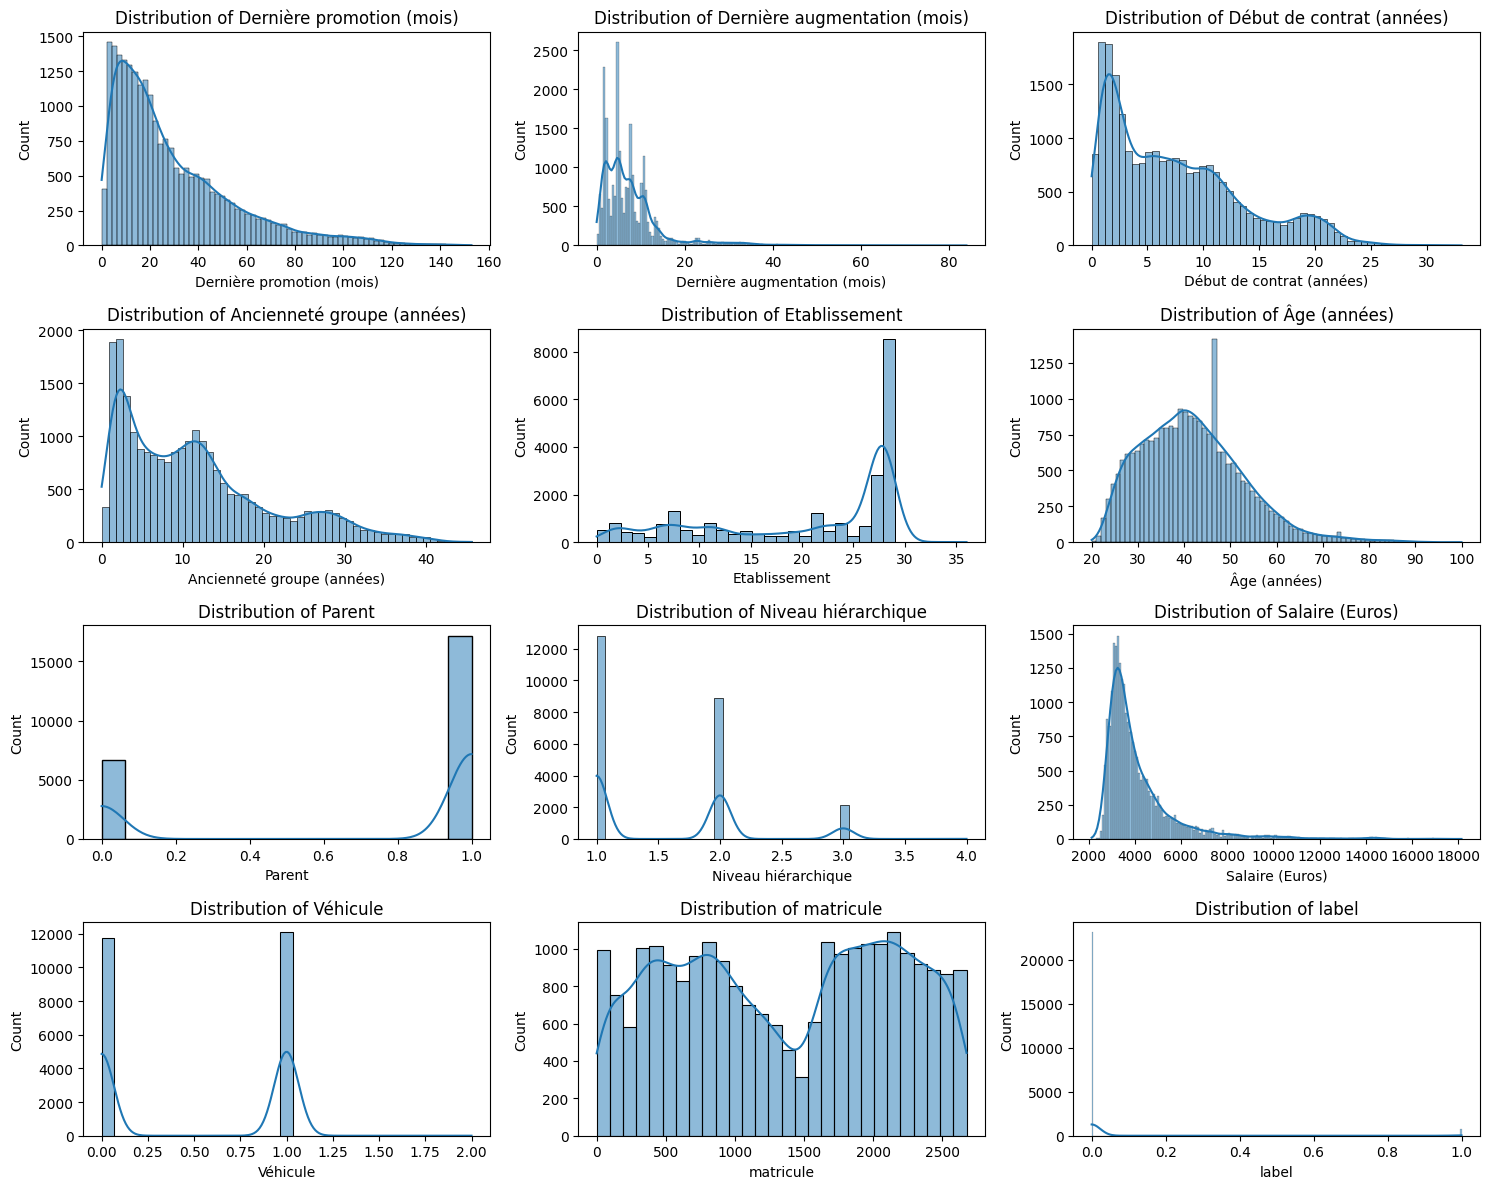

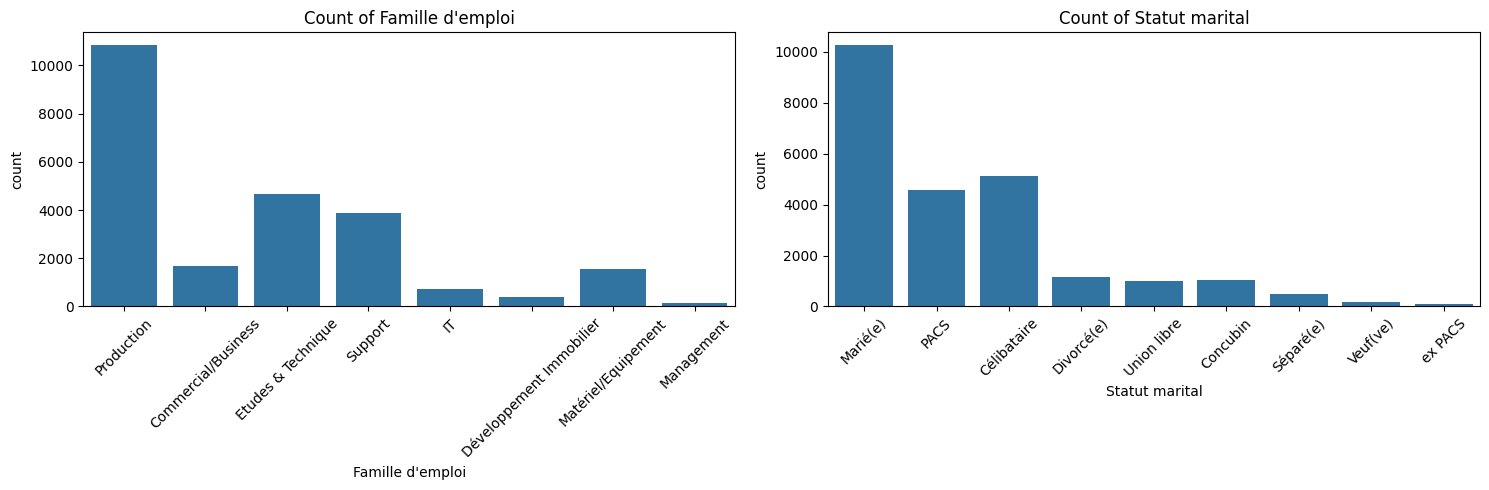

In [7]:
# Plot on the same figure in grid mode
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easy iteration
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Show histograms for categorical variables
fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(15, 5))
for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Count of {col}")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

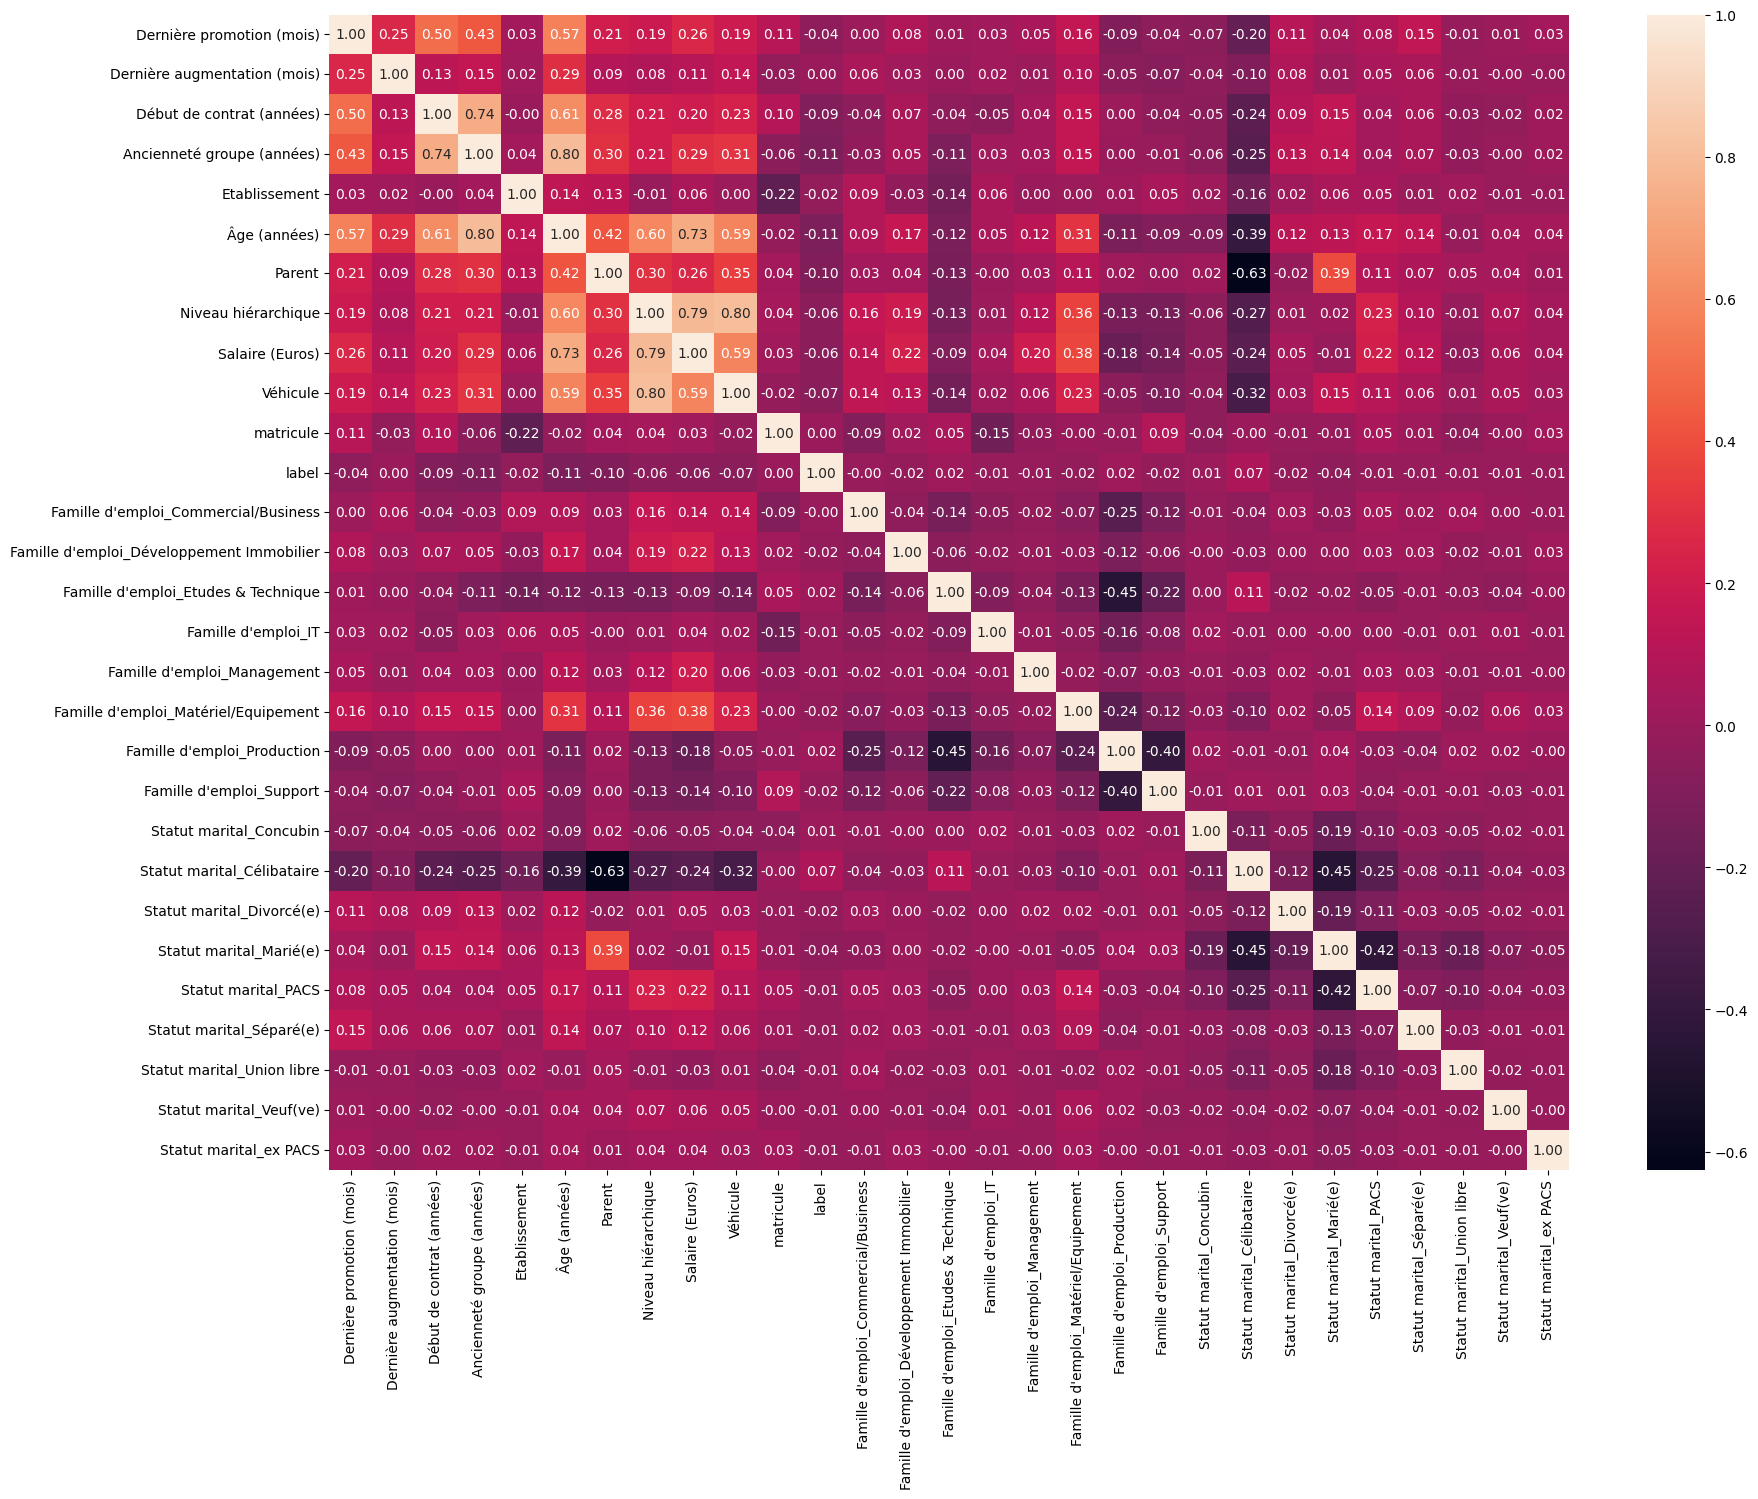

In [9]:
# Increase figure size for better readability
plt.figure(figsize=(20, 15))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f")
plt.show()

### Analyse des variables sensibles et biais potentiels

Selon la commission européenne, les données à caractère personnel suivantes sont considérées comme sensibles et font l’objet d’un traitement particulier:

* les données à caractère personnel qui révèlent l’origine raciale ou ethnique, les opinions politiques, les convictions religieuses ou philosophiques;
* l’appartenance syndicale;
* les données génétiques, les données biométriques traitées uniquement pour identifier un être humain;
* les données concernant la santé;
* les données concernant la vie sexuelle ou l’orientation sexuelle d’une personne.

Dans notre cas, les variables ne semblent donc pas permettre d'inférence de ces données à caratères sensibles. Tout au plus, l'utilisation de résultats statistiques provenant d'études sociologiques peuvent permettre de donner de légères pistes probabilistes (opinions politiques & appartenance syndicale notamment), mais de façon très marginale et très incertaine.

En revanche, selon l'article 4 (4) du RGPD, on peut également considérer comme sensibles les données utilisées pour analyser ou prédire le rendement au travail, la situation économique, les préférences personnelles, les intérêts, la fiabilité, le comportement, la localisation ou les déplacements d'une personne. (Jérémy Bensoussan, Droit, éthique et vie privée, BE 42220120 - Copyright Lexing ®)

Ainsi, des variables telles que le salaire permettent d'analyser une situation économique. D'autres, comme l'établissement donnent la localisation du lieu de travail et un indice, quoique peu précis, sur le lieu de résidence. Enfin les données sur les dernières augmentations ou promotions, bien qu'en réalité n'ayant pas forcément de liens avec le rendement au travail ou la fiabilité, peuvent être utilisées par certains acteurs (recruteurs peu scrupuleux, ...) comme en étant des indicateurs. 

En outre, les données permettant l'identification d'un individu sont également considérées comme sensibles. De ce point de vue, en croisant la connaissance de plusieurs variables, l'identification d'individus peut de plus en plus apparaître, et ce, même sans utiliser de données numériques (non ordinales):

In [7]:
N = len(df)

cols = ["Famille d'emploi", "Parent", "Niveau hiérarchique", "Statut marital", "Véhicule", "label"]
counts = df.value_counts(cols)
print(f"Nombre de personnes identifiables avec connaissance de {cols} : {(counts == 1).sum()} sur {N}") 

cols = ["Famille d'emploi", "Parent", "Niveau hiérarchique", "Statut marital", "Véhicule", "label", "Etablissement"]
counts = df.value_counts(cols)
print(f"Nombre de personnes identifiables avec connaissance de {cols} : {(counts == 1).sum()} sur {N}") 



Nombre de personnes identifiables avec connaissance de ["Famille d'emploi", 'Parent', 'Niveau hiérarchique', 'Statut marital', 'Véhicule', 'label'] : 39 sur 23857
Nombre de personnes identifiables avec connaissance de ["Famille d'emploi", 'Parent', 'Niveau hiérarchique', 'Statut marital', 'Véhicule', 'label', 'Etablissement'] : 412 sur 23857


# 3. Machine Learning

### Tree-based approach

In [10]:
from xgboost import XGBClassifier
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

**Sans one-hot encoding _Etablissement_**

In [ ]:
# Etablissement and matricule are not part of the features used by this model
X = df_encoded.drop(columns=["label", "matricule", "Etablissement"])
y = df_encoded["label"]

# Data is regrouped by matricule to avoid data leak between train and test sets
groups = df_encoded["matricule"]
splitter = GroupShuffleSplit(test_size=0.3, n_splits=1, random_state=42)
for train_idx, test_idx in splitter.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups.iloc[train_idx]

# Rebalance the importance of label 1 over label 0 to compensate the disproportion of the two classes in the dataset 
weight_balance = (y_train == 0).sum() / (0.1 * (y_train == 1).sum())

# Scaling the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
classifier = XGBClassifier(
                n_estimators=180,
                learning_rate=0.02,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                objective='binary:logistic',
                scale_pos_weight=weight_balance,
                random_state=42,
                n_jobs=-1)


# # CROSS VALIDATION
# cross_validator = GroupKFold(n_splits=5)
# for train_index, val_index in cross_validator.split(X_train, groups=groups_train):
#     X_cv_train, X_val = X_train[train_index], X_train[val_index]
#     y_cv_train, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
#     classifier.fit(X_cv_train, y_cv_train)
#     y_pred_val = classifier.predict(X_val)
#     print(classification_report(y_val,y_pred_val))

In [9]:
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

print(f"confmat : {confusion_matrix(y_test, y_pred)}")
print(classification_report(y_test,y_pred))

for name, score in zip(X.columns, classifier.feature_importances_):
    print(f"{name} : {score}")

confmat : [[3746 3131]
 [  66  155]]
              precision    recall  f1-score   support

           0       0.98      0.54      0.70      6877
           1       0.05      0.70      0.09       221

    accuracy                           0.55      7098
   macro avg       0.51      0.62      0.39      7098
weighted avg       0.95      0.55      0.68      7098

Dernière promotion (mois) : 0.0327376127243042
Dernière augmentation (mois) : 0.037602197378873825
Début de contrat (années) : 0.03990089148283005
Ancienneté groupe (années) : 0.07745479047298431
Etablissement : 0.05260559916496277
Âge (années) : 0.0406036414206028
Parent : 0.052912116050720215
Niveau hiérarchique : 0.0304192453622818
Salaire (Euros) : 0.04131278768181801
Véhicule : 0.029867811128497124
Famille d'emploi_Commercial/Business : 0.03968466445803642
Famille d'emploi_Développement Immobilier : 0.0346604622900486
Famille d'emploi_Etudes & Technique : 0.042115550488233566
Famille d'emploi_IT : 0.031086698174476624
Famil

Les résultats montrent des features importances très homogènes, comprises entre 0.03 et 0.08. Si l'ancienneté et le statut marital semblent plus importants, ils sont très loins de detenir la majorité de l'explication, et aucune des autres features ne semble vraiment négligeable.

**Avec one-hot encoding _Etablissement_**

In [13]:
X_etablissement = pd.get_dummies(df_encoded, columns=["Etablissement"], drop_first=False, dtype=int)
X = X_etablissement.drop(columns=["label", "matricule"])
y = df_encoded.label

# Data is regrouped by matricule to avoid data leak between train and test sets
groups = df_encoded["matricule"]
splitter = GroupShuffleSplit(test_size=0.3, n_splits=1, random_state=42)
for train_idx, test_idx in splitter.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups.iloc[train_idx]

# Rebalance the importance of label 1 over label 0 to compensate the disproportion of the two classes in the dataset 
weight_balance = (y_train == 0).sum() / (0.1 * (y_train == 1).sum())

# Scaling the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

classifier = XGBClassifier(
                n_estimators=180,
                learning_rate=0.02,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                objective='binary:logistic',
                scale_pos_weight=weight_balance,
                random_state=42,
                n_jobs=-1)

classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

print(f"confmat : {confusion_matrix(y_test, y_pred)}")
print(classification_report(y_test,y_pred))

for name, score in zip(X.columns, classifier.feature_importances_):
    print(f"{name} : {score}")

confmat : [[3497 3380]
 [  55  166]]
              precision    recall  f1-score   support

           0       0.98      0.51      0.67      6877
           1       0.05      0.75      0.09       221

    accuracy                           0.52      7098
   macro avg       0.52      0.63      0.38      7098
weighted avg       0.96      0.52      0.65      7098

Dernière promotion (mois) : 0.01365362573415041
Dernière augmentation (mois) : 0.016450436785817146
Début de contrat (années) : 0.01858978345990181
Ancienneté groupe (années) : 0.031565841287374496
Âge (années) : 0.021160012111067772
Parent : 0.0253798495978117
Niveau hiérarchique : 0.011388439685106277
Salaire (Euros) : 0.01874857395887375
Véhicule : 0.016172632575035095
Famille d'emploi_Commercial/Business : 0.018314843997359276
Famille d'emploi_Développement Immobilier : 0.019710933789610863
Famille d'emploi_Etudes & Technique : 0.016532907262444496
Famille d'emploi_IT : 0.01571885123848915
Famille d'emploi_Management : 0.004

Les résultats sont sensiblement identiques, avec une légère amélioration du rappel pour le label 1, mais une légère détérioration du label 0.

In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

def fairness_evaluation_with_trueDI(y_true, y_pred, X, age_bins=[20,40,60,80,100]):    
    df_eval = X.copy()
    df_eval['y_true'] = y_true
    df_eval['y_pred'] = y_pred
    
    # Tranches d'âge
    age_labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins)-1)]
    df_eval['Âge (années)'] = pd.cut(df_eval['Âge (années)'], bins=age_bins, labels=age_labels)
    
    results = {}
    
    # Sous-groupes
    subgroups = {
        'Parent': df_eval['Parent'].unique(),
        'Âge (années)': df_eval['Âge (années)'].unique()
    }
    
    # Calcul metrics
    for group_col, groups in subgroups.items():
        metrics = []
        privileged_group = groups[0]  # référence pour DI
        
        for g in groups:
            sub = df_eval[df_eval[group_col]==g]
            if len(sub)==0:
                continue
            
            # FPR / FNR
            tn, fp, fn, tp = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0,1]).ravel()
            fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
            fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
            
            # Disparate Impact sur prédiction
            p_priv_pred = df_eval[df_eval[group_col]==privileged_group]['y_pred'].mean()
            p_unpriv_pred = sub['y_pred'].mean()
            di_pred = p_unpriv_pred / p_priv_pred if p_priv_pred > 0 else np.nan
            
            # Disparate Impact sur vrai label
            p_priv_true = df_eval[df_eval[group_col]==privileged_group]['y_true'].mean()
            p_unpriv_true = sub['y_true'].mean()
            di_true = p_unpriv_true / p_priv_true if p_priv_true > 0 else np.nan
            
            metrics.append({
                'group': g,
                'count': len(sub),
                'FPR': fpr,
                'FNR': fnr,
                'DI_pred': di_pred,
                'DI_true': di_true
            })
        
        results[group_col] = pd.DataFrame(metrics)
    
    return results

In [24]:
X_test = pd.DataFrame(X_test, columns=X.columns)
results = fairness_evaluation_with_trueDI(y_test, y_pred, X_test[['Parent','Âge (années)']])

for group_col, df_metrics in results.items():
    print(f"\n{group_col}")
    print(df_metrics.to_string(index=False))

C:\Users\MickaelMartinelliCS\AppData\Roaming\Python\Python313\site-packages\sklearn\externals\array_api_compat\numpy\_aliases.py:125: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype=dtype, copy=copy)


ValueError: Input y_true contains NaN.